### Human in the loop in Langgraph workflow

Usecase:

Interruption for human feedback in the graph which is bind to custom tools.

In [34]:
#importing libraries

import os
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langchain.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.checkpoint.memory import MemorySaver

from typing import List, Annotated
from typing_extensions import TypedDict

from pprint import pprint

load_dotenv()

True

In [35]:
#defining custom tools

@tool
def multiply(x:int, y:int)->int:
    "this function performs multiplication operation on given values and returns output"
    return x*y

tavily_tool = TavilySearch(max_results=3)



### Human in the loop with LLM


In [36]:
my_tools = [tavily_tool, multiply]

model_tools = init_chat_model(model="groq:llama-3.1-8b-instant").bind_tools(my_tools)
model_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000013F56576ED0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000013F56C9A600>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input sho

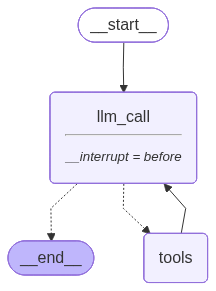

In [37]:
#defining schema and workflow with hitl

class State(TypedDict):
    messages : Annotated[List, add_messages]

def llm_call(state:State):
    response = model_tools.invoke(state['messages']) 
    return {"messages": [response]}   

tools = ToolNode(my_tools)


graph_builder = StateGraph(State)

graph_builder.add_node("llm_call", llm_call)
graph_builder.add_node("tools", tools)

graph_builder.add_edge(START, "llm_call")
graph_builder.add_conditional_edges("llm_call", tools_condition)
graph_builder.add_edge("tools", "llm_call")

graph = graph_builder.compile(interrupt_before=["llm_call"], checkpointer=MemorySaver())
graph



In [38]:
#invoking graph
query="give me most recent news on agentic ai"
config={"configurable":{"thread_id":"user_model"}}

for event in graph.stream({"messages": query},stream_mode="values", config=config):
    event['messages'][-1].pretty_print()



================================ Human Message =================================

give me most recent news on agentic ai


In [39]:
[state for state in graph.get_state_history(config=config)]

[StateSnapshot(values={'messages': [HumanMessage(content='give me most recent news on agentic ai', additional_kwargs={}, response_metadata={}, id='cc5e6459-cf53-4e5c-a777-5e466a0d7655')]}, next=('llm_call',), config={'configurable': {'thread_id': 'user_model', 'checkpoint_ns': '', 'checkpoint_id': '1f0e9cea-d90e-68f1-8000-6017654aad51'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-01-05T00:37:13.297534+00:00', parent_config={'configurable': {'thread_id': 'user_model', 'checkpoint_ns': '', 'checkpoint_id': '1f0e9cea-d909-6a8e-bfff-ab97c3e42312'}}, tasks=(PregelTask(id='ac285c4e-69f9-7483-dc8e-3d9289302ad4', name='llm_call', path=('__pregel_pull', 'llm_call'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'messages': []}, next=('__start__',), config={'configurable': {'thread_id': 'user_model', 'checkpoint_ns': '', 'checkpoint_id': '1f0e9cea-d909-6a8e-bfff-ab97c3e42312'}}, metadata={'source': 'input', 'step': -1,

In [40]:
graph.get_state(config=config).next

('llm_call',)

In [41]:
for event in graph.stream(None,stream_mode="values", config=config):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

give me most recent news on agentic ai
================================== Ai Message ==================================
Tool Calls:
  tavily_search (mdp8v6njn)
 Call ID: mdp8v6njn
  Args:
    query: agentic AI latest news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "agentic AI latest news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/lanceeliot/2026/01/04/a-years-worth-of-analyses-and-insights-about-the-avid-pursuit-of-agi-and-ai-superintelligence/", "title": "A Year’s Worth Of Analyses And Insights About The Avid Pursuit Of AGI And AI Superintelligence - Forbes", "score": 0.37072703, "published_date": "Sun, 04 Jan 2026 08:15:00 GMT", "content": "* “Future Forecasting The AGI To ASI Pathway Giving Rise To AI Superintelligence” by Dr. Lance